# Relativistic Boris-C Particle Simulation in Earth's Dipole Field

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('.'))

from rel_boris_c_dipole import init_cond, run_simulation, plot_results

## 1–Physical Setup

### Magnetic field

Earth's dipole field with a **11.7° geographic–geomagnetic tilt**:

$$\mathbf{B}(\mathbf{r}) = -\frac{M_E}{r^5}\left[3(\hat{\mathbf{m}}\cdot\mathbf{r})\,\mathbf{r} - r^2\hat{\mathbf{m}}\right]$$

where $\hat{\mathbf{m}}$ is the magnetic moment and  $M_E = 7.97\times10^{15}\;\text{T\,m}^3$

### Particles

We simulate three particles:

| Particle | Speed ($\beta$) | Kinetic energy | $x_0$ |
|:---------|:--------------:|:--------------:|:------:|
| Proton        | $0.616\,c$ | ~253 MeV | $2.5\,R_E$ |
| Electron      | $0.94\,c$  | ~1 MeV   | $4.5\,R_E$ |
| Alpha particle | $0.50\,c$  | ~577 MeV | $2.5\,R_E$ |

All particles start at $y = z = 0$ on the equatorial plane with equatorial pitch angle
$\alpha_{eq} = 30°$:

$$v_y = v\sin\alpha_{eq} \;(\perp\mathbf{B}), \qquad v_z = v\cos\alpha_{eq} \;(\|\mathbf{B})$$

### Integration parameters

Timesteps and simulation durations are chosen per particle to resolve several gyrations and bounce cycles:

| Particle | $dt$ [s] | $T_{\rm sim}$ [s] | stored every |
|:---------|:--------:|:-----------------:|:------------:|
| Proton        | $10^{-4}$ | 6.0 | 10 steps |
| Electron      | $10^{-6}$ | 1.5 | 20 steps |
| Alpha particle | $10^{-4}$ | 6.0 | 10 steps |

### Characteristic timescales and adiabaticity

Trapped-particle motion in a dipole separates into three quasi-periodic components: gyration about the field line, bounce between mirror points, and azimuthal drift around the Earth. The overall expected motion is sketched in the following figure (taken from Walt M., 1994):

<img src="figures/trajectories_reference.png"> 

For our initial conditions at the equator (see appendix for the formulas):

| Particle | $\gamma$ | $T_{g}$ | $r_g$ | $\epsilon=r_g/r$ | $\tau_{b}$ | $\tau_{d}$ | $\lambda_m$ | $r_{m}$ | $\alpha_{LC}$ $(R_a=R_E)$|
|---|---|---|---|---|---|---|---|---|---|
| Proton | 1.269 | 42.22 ms | 0.0974 $R_E$ | 0.0390 | 0.344 s | 6.92 s | 33.15° | 1.752 $R_E$ | 11.28° |
| Electron | 2.955 | 0.312 ms | 0.0011 $R_E$ | 0.0002 | 0.405 s | 50.39 min | 33.15° | 3.154 $R_E$ | 4.45° | 
| Alpha | 1.155 | 76.27 ms | 0.1428 $R_E$ | 0.0571 | 0.424 s | 5.28 s | 33.15° | 1.752 $R_E$ | 11.28° |

From these three points follow:

1. **The electron is deeply adiabatic** ($\varepsilon \sim 4\times10^{-4}$): its magnetic moment $\mu = p_\perp^2/2mB$ is conserved to high accuracy and its trajectory is a textbook guiding-center orbit.
2. **The proton and especially the alpha are only marginally adiabatic** ($\varepsilon \sim 0.07$–$0.10$). The gyroradius is a non-negligible fraction of the distance to Earth, so finite-Larmor-radius effects are visible: the guiding-center picture holds only approximately, $\mu$ suffers small jumps at each equatorial crossing, and the drift shell is visibly "wobbly." This is the regime approaching Störmer-type (non-adiabatic) dynamics — physically genuine, not a numerical artifact.
3. **The simulation durations sample very different fractions of each motion.** In 6 s the proton executes ~140 gyrations, ~21 bounces and ≈1 full drift orbit; the alpha ~78 gyrations, ~18 bounces and ≈1 drift orbit. In 0.6 s the electron executes ~1900 gyrations but only ~2 bounces and ~0.2° of azimuthal drift ($\tau_d \approx 15$ min ≫ $T_{sim}$).

The initial conditions are loaded from ```particles.yaml``` and the above mentioned physical quantities are calculated internally.

In [2]:
particles = init_cond('particles.yaml')

Initialized Proton:
r0 = [2.5, 0.0, 0.0] RE   v0 = 0.616 c
alpha = 30.0 deg   ke = 2.53e+08 eV

With derived quantities:
gamma=1.2694,  Beq=1964.8 nT
Tgyro=42.380 ms  rg=0.0976 RE   eps=0.0391
tau_bounce=0.3440 s   tau_drift=6.9042 s (0.115 min)
mirror_lat=33.15 deg   r_mirror=1.752 RE
loss_cone(surface)=11.278 deg

Initialized Electron:
r0 = [4.5, 0.0, 0.0] RE   v0 = 0.941 c
alpha = 30.0 deg   ke = 1.00e+06 eV

With derived quantities:
gamma=2.9570,  Beq=336.9 nT
Tgyro=0.314 ms  rg=0.0011 RE   eps=0.0002
tau_bounce=0.4053 s   tau_drift=3017.5583 s (50.293 min)
mirror_lat=33.15 deg   r_mirror=3.154 RE
loss_cone(surface)=4.447 deg

Initialized Alpha particle:
r0 = [2.5, 0.0, 0.0] RE   v0 = 0.500 c
alpha = 30.0 deg   ke = 5.77e+08 eV

With derived quantities:
gamma=1.1547,  Beq=1964.8 nT
Tgyro=76.571 ms  rg=0.1432 RE   eps=0.0573
tau_bounce=0.4238 s   tau_drift=5.2758 s (0.088 min)
mirror_lat=33.15 deg   r_mirror=1.752 RE
loss_cone(surface)=11.278 deg



## 2–Running the Simulation

Each particle is integrated twice: once with **Boris-C** (full trajectory stored) and once with **RK4** (full $\gamma$ history stored at the same cadence, for the energy comparison plot). The table reports the relative Lorentz factor error $|\Delta\gamma/\gamma_0|$ at the end of each run.

In [3]:
results = run_simulation(particles)

RK4      Alpha particle: 100%|██████████| 60000/60000 [00:04<00:00, 14508.61it/s]


  Particle         Method     gamma_0 gamma_final gamma_error
  ───────────────────────────────────────────────────────────
  Proton           Boris-C     1.2694     1.2694   6.65e-15
                   RK4         1.2694     1.2694   9.51e-07
  Electron         Boris-C     2.9570     2.9570   3.71e-14
                   RK4         2.9570  2035.2145   6.87e+02
  Alpha particle   Boris-C     1.1547     1.1547   1.92e-16
                   RK4         1.1547     1.1537   8.91e-04



## 3–Trajectories

Each particle is plotted individually. Every panel includes a 3D trajectory and the equatorial ($xy$) and meridional ($xz$) projections.

### Proton

- The proton (253 MeV, $L=2.5\,R_E$, $\gamma=1.269$) is launched with equatorial pitch angle $\alpha_{eq}=30°$, giving a gyroradius $r_g\approx0.04$ of the local radial distance — small enough to remain in the adiabatic regime, but large enough that individual gyro-loops are visible in the plot.
- The tight loops trace the **gyration** about the local field line; their size shrinks as the particle bounces toward stronger field near the mirror points and grows again near the equator.
- The meridional (xz) excursion shows the **bounce motion**: at $\alpha_{eq}=30°$ the particle mirrors at magnetic latitude $\approx33°$, corresponding to a mirror-point distance of $r_m\approx1.75\,R_E$ — noticeably closer to Earth than the equatorial launch point, since a smaller pitch angle pushes the mirror point deeper into the stronger-field region.
- The equatorial (xy) projection closes into a ring: with $T_{drift}\approx5.5$ s and $T_{sim}=6$ s, the proton completes just over one full **gradient–curvature drift** orbit, moving westward as expected for a positive charge. 

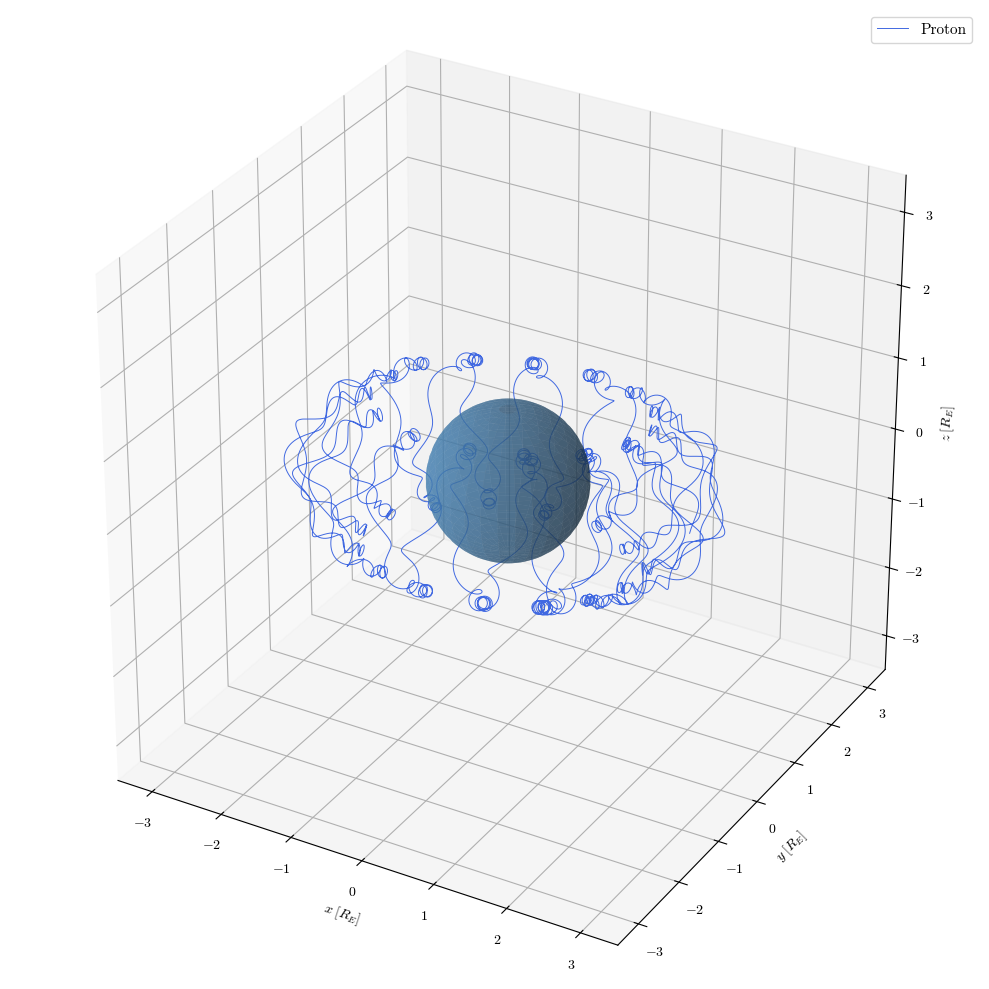

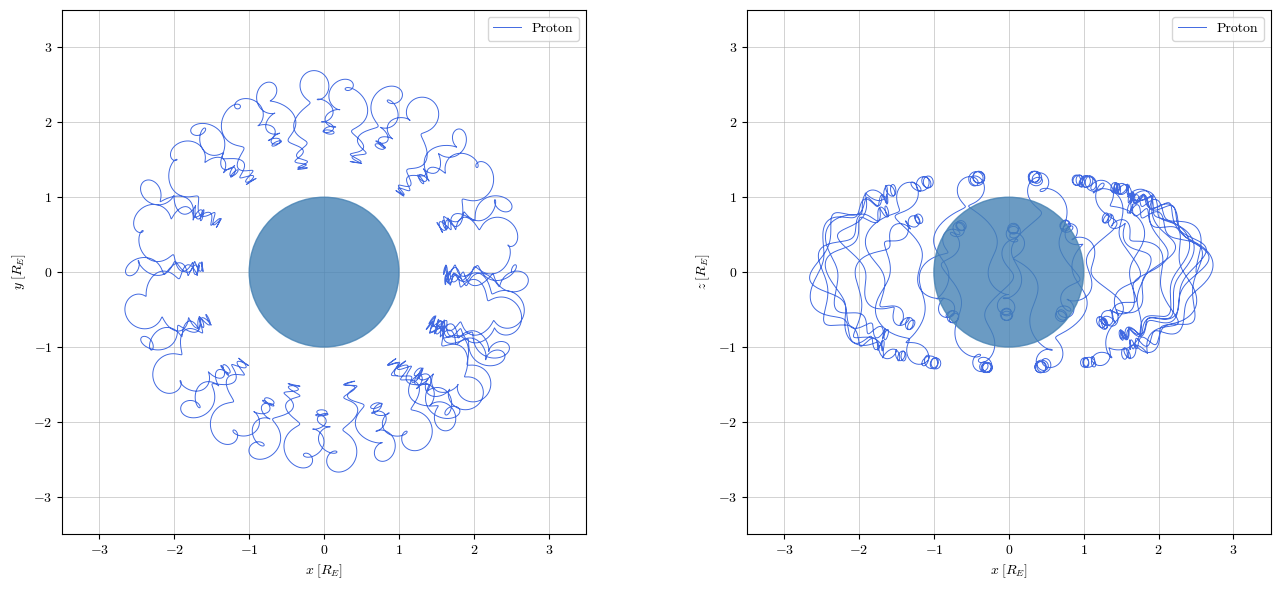

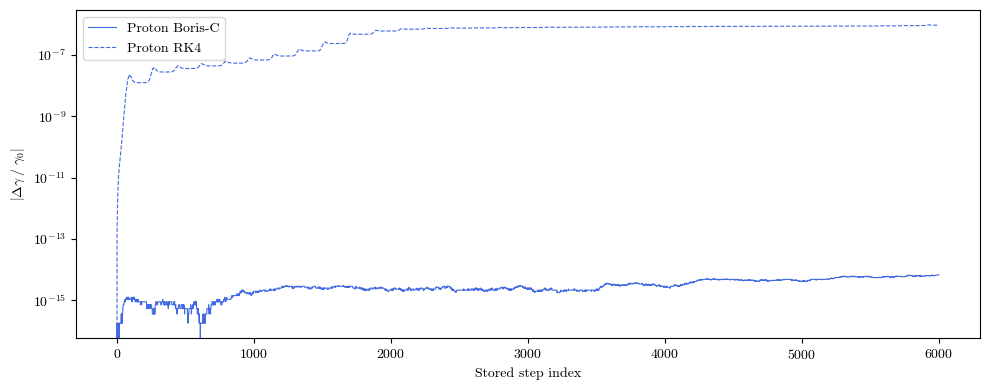

In [4]:
plot_results({'Proton': results['Proton']}, save=False, lim=3.5)

### Electron

- The electron (1 MeV, $L=4.5\,R_E$, $\gamma=2.955$) is highly relativistic ($\beta=0.941$) but has a gyroradius of only tens of kilometers — a factor $\sim10^{2}$–$10^{3}$ smaller, relative to $L$, than either ion. The gyration is therefore invisible at the plotted scale, and the trajectory shown is effectively the pure **guiding-center bounce orbit**.
- With $\alpha_{eq}=30°$, the electron mirrors at magnetic latitude $\approx33°$, i.e. $r_m\approx3.15\,R_E$ — well above the loss-cone limit ($\alpha_{lc}\approx4.5°$ at $L=4.5$), so it is stably and comfortably trapped.
- Over the simulated interval ($T_{sim}=1.5$ s at $dt=10^{-6}$ s), the electron completes roughly 3–4 full bounce cycles between its northern and southern mirror points, tracing the same arc back and forth along the field line.
- Azimuthal drift is essentially unobservable on this timescale: $T_{drift}\approx50$ minutes, so 1.5 s corresponds to a small fraction of a degree of eastward longitudinal motion (electrons drift eastward, opposite to positive ions). 

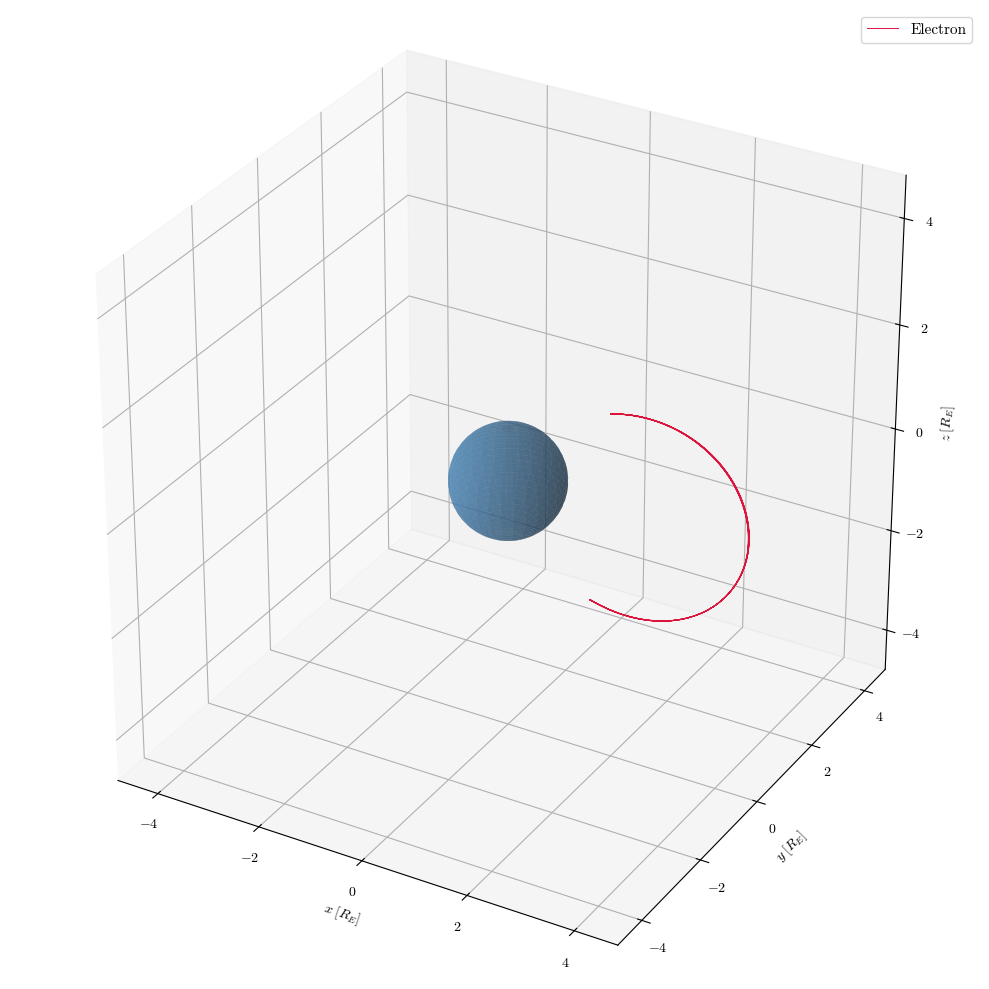

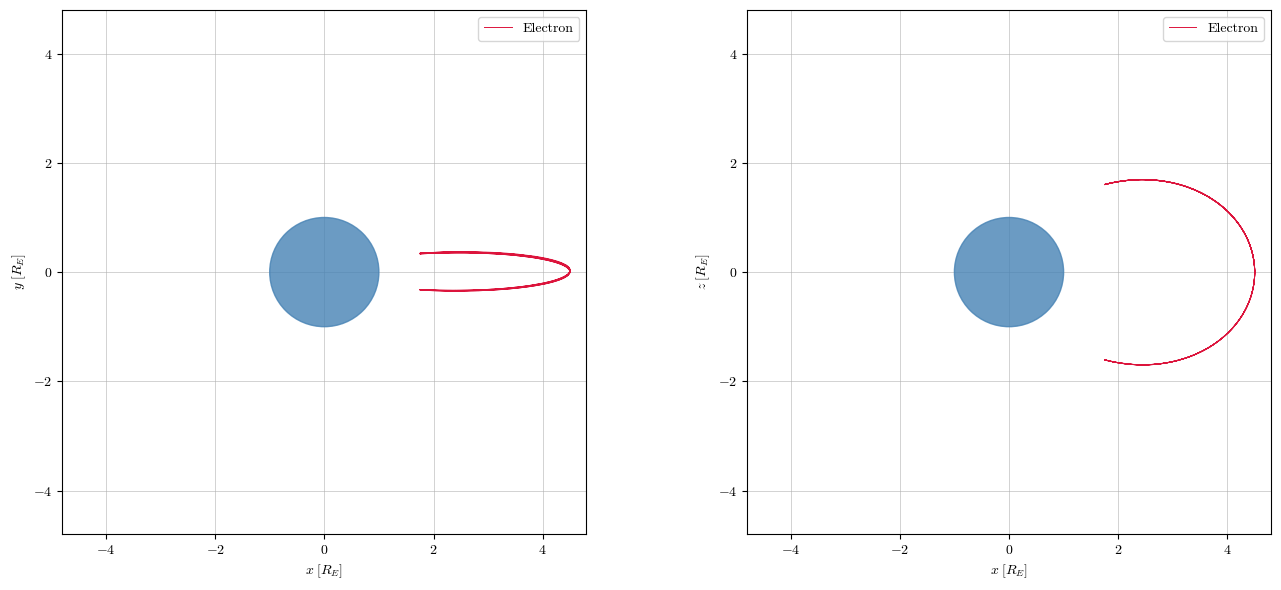

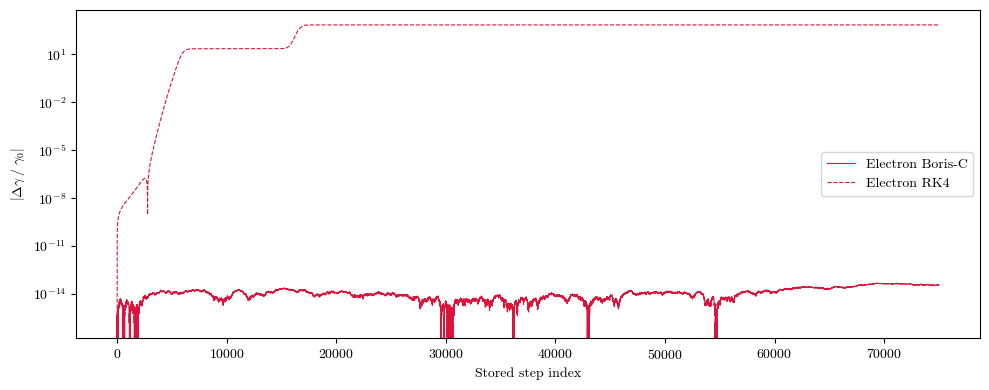

In [5]:
plot_results({'Electron': results['Electron']}, save=False, lim=4.8)

### Alpha particle

- The alpha particle (577 MeV total, $\sim144$ MeV/nucleon, $L=2.5\,R_E$, $\gamma=1.155$) shares its launch point, $L$-shell, and pitch angle with the proton, isolating the effect of **rigidity** (momentum-to-charge ratio) on the orbit.
- Its gyroradius fraction $\varepsilon=r_g/r\approx0.057$ is larger than the proton's ($\approx0.039$), since the alpha's charge-to-mass ratio is roughly half the proton's at comparable $\gamma$. The gyro-loops are correspondingly larger and the drift shell visibly less smooth
- Mirror geometry is identical to the proton's by construction (same $\alpha_{eq}=30°$, same $L$): mirror latitude $\approx33°$, $r_m\approx1.75\,R_E$.
- The equatorial projection again closes into slightly more than one full drift orbit ($T_{drift}\approx4.6$ s over $T_{sim}=6$ s), westward as for any positive charge, but the ring is less circular than the proton's — the larger gyroradius means the guiding-center approximation holds less precisely, so each drift-orbit pass deviates a little more from a perfect circle.

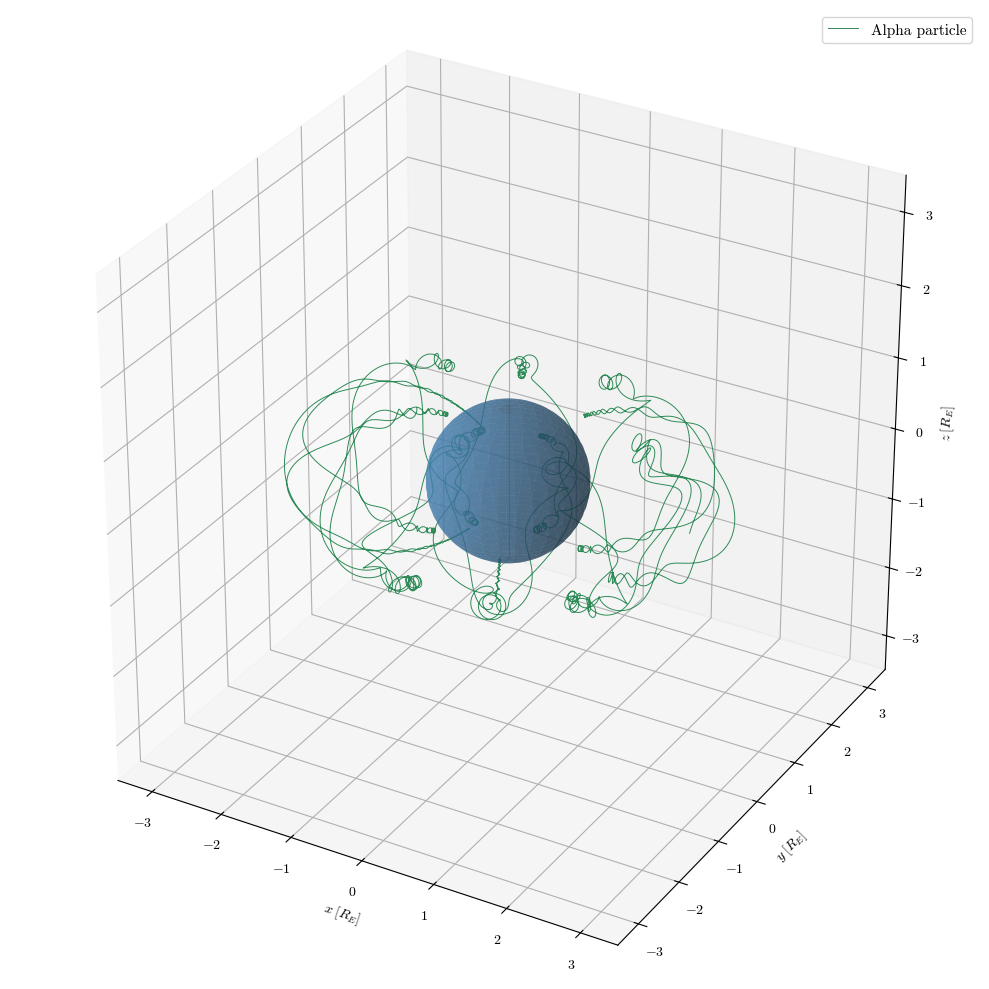

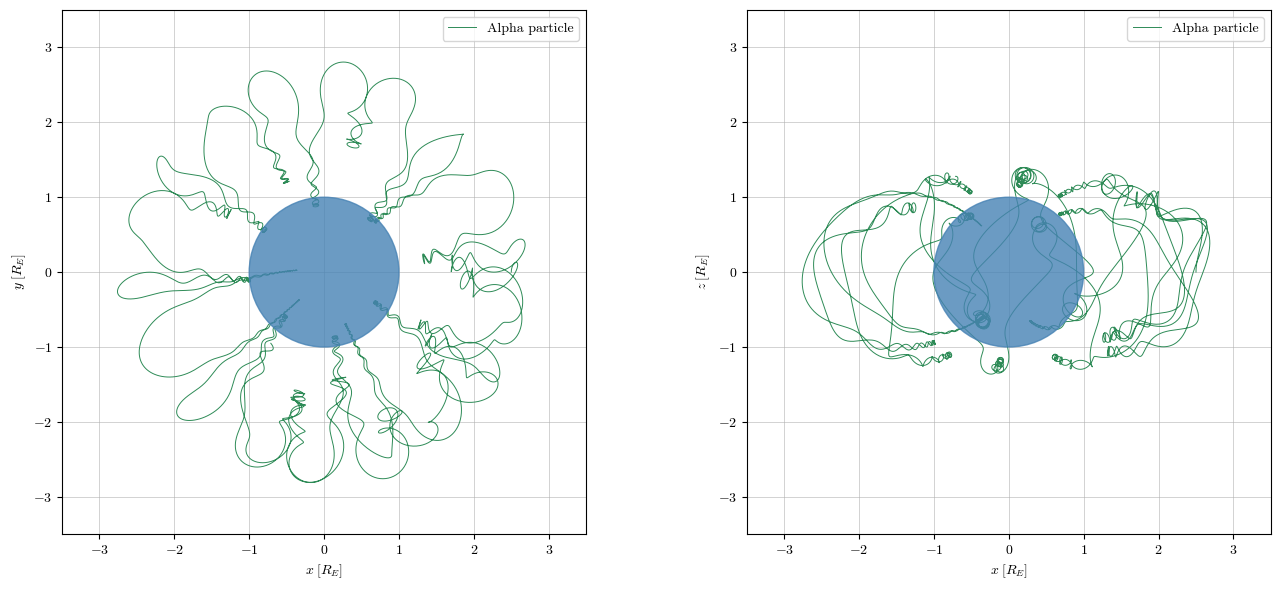

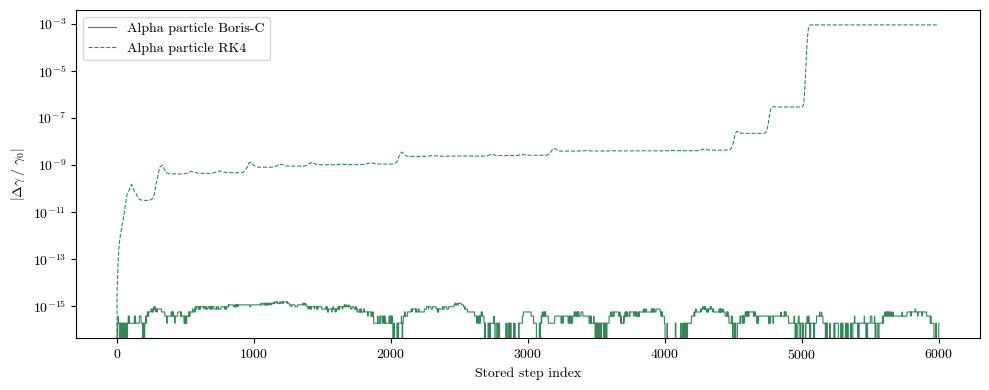

In [6]:
plot_results({'Alpha particle': results['Alpha particle']}, save=False, lim=3.5)

## 4–Energy conservation: Boris-C vs. RK4

- In a pure magnetic field ($\mathbf{E}=0$), the Lorentz force $q\mathbf{v}\times\mathbf{B}$ is always perpendicular to $\mathbf{v}$, so it does no work: $\gamma$ is an exact constant of motion at the level of the continuous equations.
- The Boris-C algorithm advances the momentum by applying an **exact rotation** to $\mathbf{u}=\gamma\mathbf{v}$ at each step. A rotation preserves vector magnitude by construction, so $|\mathbf{u}|$ — and therefore $\gamma=\sqrt{1+|\mathbf{u}|^2/c^2}$ — is conserved to within floating-point round-off ($\sim10^{-14}$–$10^{-15}$), regardless of how long the integration runs or how sharply $\mathbf{B}$ varies along the orbit.
- RK4 has no equivalent geometric constraint: it approximates the trajectory with a generic polynomial expansion that does not respect the rotational structure of the magnetic force, so its energy error is free to grow with each step.
- The growth is not smooth — it is concentrated at each pass through the strongest-field region of the orbit (the mirror points), where the local gyroperiod is shortest relative to the fixed timestep and the per-step truncation error is largest. The result is a **staircase**: long flat plateaus between bounces, punctuated by discrete jumps timed to each mirror-point passage.
- For the proton and alpha this staircase stays bounded (final $|\Delta\gamma/\gamma_0|\sim10^{-6}$–$10^{-4}$ over 6 s); for the electron, enough bounce-synchronized kicks accumulate that RK4 becomes fully unstable and $\gamma$ diverges by orders of magnitude — even though its per-gyration resolution (~313 steps) is finer than the ions'. Boris-C shows none of this sensitivity: its error stays flat at round-off in every case.

## 5–Comparison and Conclusion

- All three particles — proton, electron, alpha — are stably trapped at $\alpha_{eq}=30°$, safely outside their respective loss cones (11.3° at $L=2.5$, 4.5° at $L=4.5$), and all show the expected three-tier hierarchy of trapped motion: gyration, bounce, and drift, with $T_{gyro}\ll T_{bounce}\ll T_{drift}$ in every case.
- **Adiabaticity scales with rigidity, not species identity.** The electron, despite being the most relativistic particle simulated ($\gamma=2.955$), is also the most adiabatic ($\varepsilon\sim2\times10^{-4}$) because its gyroradius is tiny compared to $L$. The proton and alpha, with $\varepsilon\sim0.04$–$0.06$, show visibly coarser, less circular drift shells — finite-Larmor-radius corrections to the guiding-center picture that are absent for the electron.
- **Energy conservation separates cleanly by integrator, not by particle.** Boris-C holds $|\Delta\gamma/\gamma_0|$ at round-off ($\sim10^{-14}$) for all three particles over the full run, independent of pitch angle, mirror depth, or rigidity. RK4, at identical timesteps, accumulates error in discrete jumps synchronized with each bounce/mirror-point passage — bounded for the proton and alpha ($10^{-6}$–$10^{-4}$), but fully unstable for the electron, whose $\gamma$ diverges by three orders of magnitude despite its comparatively fine per-gyration resolution.
- **Overall:** the trajectories reproduce the correct qualitative and quantitative picture of radiation-belt particle motion — trapping, bounce, and drift consistent with dipole theory — while the energy-conservation comparison demonstrates that this fidelity depends critically on using a structure-preserving integrator (Boris-C) rather than a generic one (RK4), particularly for particles whose bounce motion repeatedly samples strong-field, high-curvature regions of the field.

## References

1. Walt, M Introduction to Geomagnetically Trapped Radiation. Cambridge University Press; 1994.
2. Zenitani & Umeda, *Physics of Plasmas* **25**, 112110, 2018

## Appendix — Derivation of Physical Quantities

All timescales, radii, and angles in this notebook follow the results in Walt (1994), *Introduction to Geomagnetically Trapped Radiation*.

### Gyromotion, adiabaticity, and pitch angle

The first adiabatic invariant $\mu=p_\perp^2/2m_0B$ is conserved along the trajectory, giving $p^2\sin^2\alpha/B=\text{const}$ (Eq. 4.22). This relation that determines how pitch angle and gyroradius evolve as the particle moves along the field line:

$$T_{gyro}=\frac{2\pi\gamma m}{qB_{eq}}, \qquad r_g=\frac{\gamma m v\sin\alpha_{eq}}{qB_{eq}}, \qquad \varepsilon=\frac{r_g}{LR_E}$$

### Mirror latitude

Along a dipole field line at equatorial crossing $R_0=LR_E$, the field magnitude at magnetic latitude $\lambda$ is (Walt Eqs. 3.18/3.22):

$$r(\lambda)=LR_E\cos^2\lambda, \qquad \frac{B(\lambda)}{B_{eq}}=\frac{\sqrt{1+3\sin^2\lambda}}{\cos^6\lambda}$$

Conservation of the first invariant (Walt Eq. 4.22, $p^2\sin^2\alpha/B=\text{const}$) relates the pitch angle at any point on the line to the equatorial pitch angle (Eq. 4.24):

$$\sin^2\alpha(\lambda) = \sin^2\alpha_{eq}\cdot\frac{B(\lambda)}{B_{eq}}$$

The mirror point is where $\alpha=90°$, i.e. $\sin^2\alpha=1$. Setting $\lambda=\lambda_m$ there and solving for $\sin^2\alpha_{eq}$:

$$\sin^2\alpha_{eq} = \frac{\cos^6\lambda_m}{\sqrt{1+3\sin^2\lambda_m}} \ \ (\text{solved numerically for }\lambda_m), \qquad r_m=L\cos^2\lambda_m$$

### Bounce period

An approximate solution, accurate to ~0.5% is given by (Eq. 4.28):

$$\tau_b = 0.117\left(\frac{R_0}{R_E}\right)\frac{1}{\beta}\Big[1-0.4635(\sin\alpha_{eq})^{3/4}\Big]\ \text{s}, \qquad R_0=LR_E$$


### Drift period 

An approximate solution, accurate to ~0.5% is given by (Eq. 4.46/4.47):

$$\tau_d = \frac{2\pi q B_0 R_E^3}{mv^2}\cdot\frac{1}{R_0}\Big[1-0.3333(\sin\alpha_{eq})^{0.62}\Big]$$


### Loss cone

Walt defines the loss cone using $\sin^2\alpha_{LC}=B_{eq}/B_a$, where $B_a$ is the field strength at the top of the atmosphere ($\sim100$ km) on the particle's own field line. So we just need $B_a$. First we find the latitude where the field line hits the atmosphere top ($r=R_a$):

$$\cos^2\lambda_{top} = \frac{R_a}{LR_E} \equiv x$$

Then we plug into the $B$-ratio formula (eq. 3.22) to get $B_a/B_{eq}$, then invert:
$$\sin^2\alpha_{LC} = \frac{B_{eq}}{B_a} = \frac{x^3}{\sqrt{4-3x}}, \qquad x=\frac{R_a}{LR_E}$$

Setting $R_a=R_E$ ($x=1/L$) simplifies to 

$$\sin^2\alpha_{LC}=1/\sqrt{4L^6-3L^5}$$